# Planning experiments with PFNet predictions

This notebook shows how PFNet predictions can guide HX-MS experiment design. We start from a deliberately truncated dataset with only early timepoints, identify a low-confidence region, and then test whether adding longer labeling times improves the inferred exchange rates.

In this tutorial you will:
1. Build a short-time-window HX-MS dataset and run PFNet inference.
2. Inspect the residue-level confidence profile and identify a low confidence region.
3. Compare peptide uptake behavior to understand why the region is unreliable
4. Add longer timepoints, rerun PFNet, and evaluate whether the new design improves confidence.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pigeon_feather.hxio import get_all_statics_info, write_HXMS_files
from pigeon_feather.plot import UptakePlot

from pfnet.run_inference import _load_data, predict
from pfnet.utilts import create_logP_df

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


## Build a short-time-window dataset

We begin from the full example dataset, then keep only timepoints up to `3000 s`. This simulates a common experimental design problem: the data capture early exchange well, but may miss slower-exchanging regions that need longer labeling times.


In [2]:
source_input_path = Path("../examples/EEHEEEEHEE_rd4_0871.hxms")
dataset, batch, hxms_data = _load_data(str(source_input_path), centroid_model=False)

all_peptides = [peptide for state in hxms_data.states for peptide in state.peptides]
for peptide in all_peptides:
    peptide.timepoints = [tp for tp in peptide.timepoints if tp.deut_time == np.inf or tp.deut_time <= 3000.0]

write_HXMS_files([hxms_data], "GR1_short.hxms")

Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
Wrote ./GR1_short.hxms_Expt..hxms


## Set input and output paths

As in the main tutorial, we define the HX-MS input file and an output directory for PFNet results and uptake plots.


In [3]:
input_path = Path("./GR1_short.hxms_Expt..hxms")
output_path = Path("./pfnet_output_GR1_short")
output_path.mkdir(parents=True, exist_ok=True)

input_path, output_path

(PosixPath('GR1_short.hxms_Expt..hxms'), PosixPath('pfnet_output_GR1_short'))

## Run PFNet inference on the short-window dataset

This first PFNet run represents what we could infer if the experiment only contained early timepoints.


In [4]:
output = predict(
    input=str(input_path),
    output_json=str(output_path / "pfnet_results.json"),
    centroid_model=False,
    refinement=False,
    uptake_plots=True,
    plots_dir=str(output_path / "uptake_plots"),
    benchmark=False,
)

loading PFNet model
Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
plotting uptake plots


## Inspect the residue-level confidence

We first collect the main PFNet outputs, then visualize the residue-level `log(kex)` predictions. Low-confidence segments are the first hint that the current dataset may not provide enough information for that region.


<Axes: xlabel='Resid', ylabel='-log_kex'>

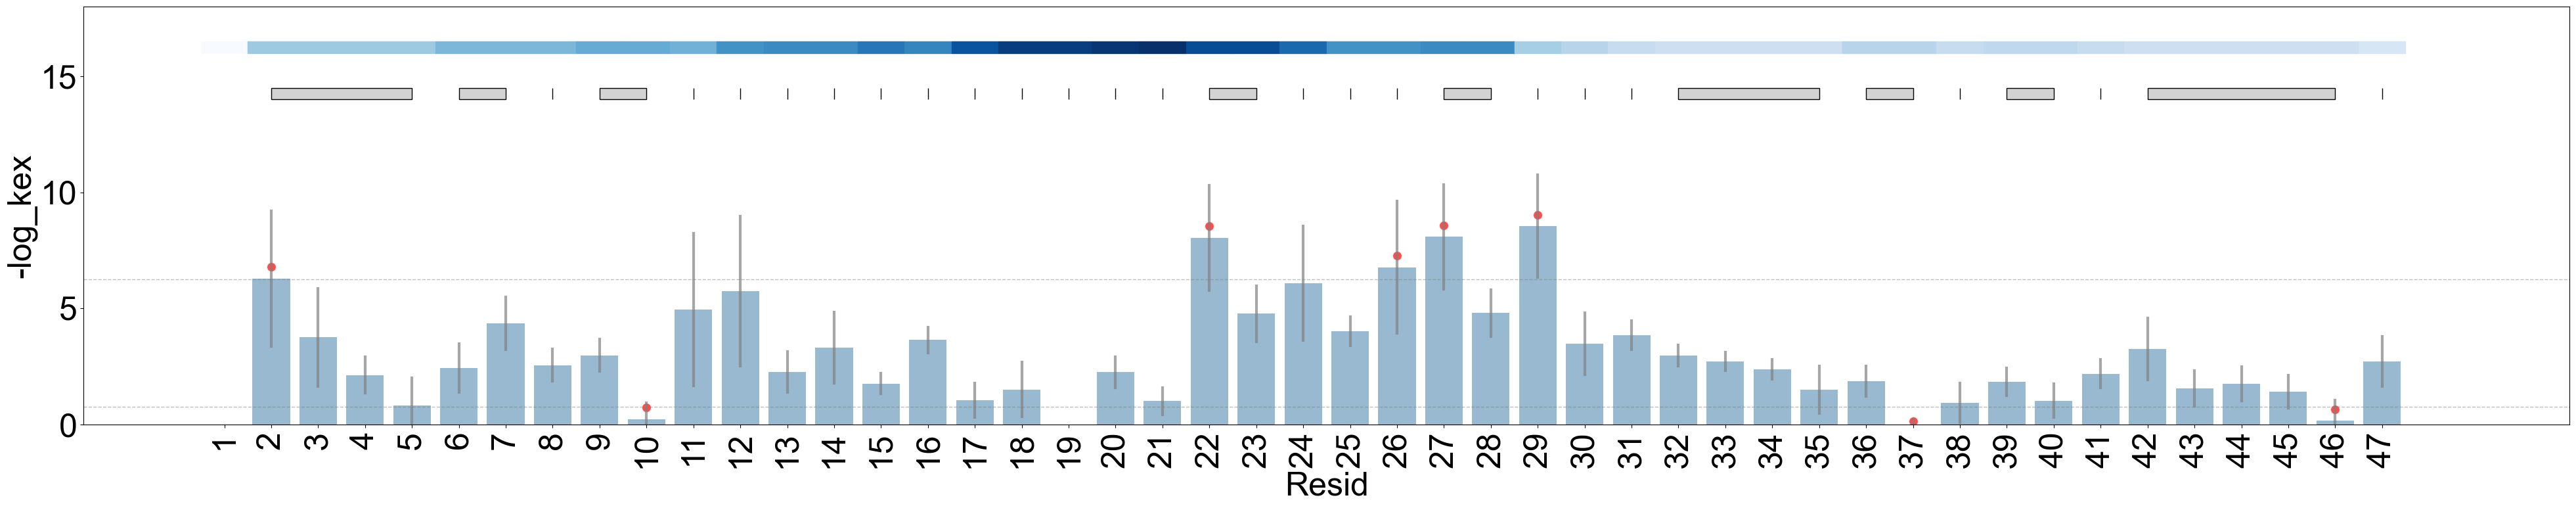

In [5]:
results = output["results"]
analysis_objs = output["analysis_objs"]

fig, ax = plt.subplots(1, 1, figsize=(40, 8), sharey=True, sharex=True)
analysis_objs["analysis_pfnet"].plot_kex_bar(
    ax=ax,
    resolution_indicator_pos=14,
    show_seq=False,
    show_coverage=True,
)

### Zoom in on the low-confidence region

In this run, residues around `22-30` stand out as a low-confidence region. The table below makes it easier to inspect the predicted `log(kex)` values together with PFNet confidence scores.


In [6]:
confidence_df = create_logP_df(
    analysis_objs["analysis_pfnet"],
    index_offset=0,
    pfnet_confidence=results["pfnet_pred_log_kex_confidence"],
)

confidence_df.iloc[17:31]

,resid,resname,avg_dG (kJ/mol),std_dG (kJ/mol),avg_logP (log(sec^-1)),std_logP (log(sec^-1)),log_kch (log(sec^-1)),log_kex (log(sec^-1)),is_nan,coverage,PFNet_confidence,single_resolved,min_pep logPs,min_pep log_kex
17,18,N,12.250,6.611,2.183,1.178,0.664,-1.519,False,35.0,0.828631,True,[2.183],[-1.519]
18,19,P,0.000,0.000,0.000,0.000,-inf,-inf,False,35.0,-100.000000,True,[nan],[-inf]
19,20,E,10.058,3.674,1.792,0.655,-0.464,-2.256,False,36.0,0.900817,True,[1.792],[-2.256]
20,21,E,3.717,3.209,0.662,0.572,-0.350,-1.012,False,37.0,0.912798,True,[0.662],[-1.012]
21,22,A,34.561,9.748,6.158,1.737,-0.252,-6.410,False,33.0,0.696723,False,"[7.793, 4.523]","[-8.046, -4.775]"
22,23,K,35.044,9.748,6.244,1.737,-0.166,-6.410,False,33.0,0.824507,False,"[7.879, 4.609]","[-8.046, -4.775]"
23,24,K,33.903,13.865,6.041,2.470,-0.046,-6.087,False,29.0,0.674209,True,[6.041],[-6.087]
24,25,F,21.236,3.473,3.784,0.619,-0.246,-4.030,False,23.0,0.905957,True,[3.784],[-4.03]
25,26,A,37.688,16.034,6.715,2.857,-0.066,-6.781,False,23.0,0.633873,True,[6.715],[-6.781]
26,27,D,36.093,9.141,6.431,1.629,-0.016,-6.447,False,24.0,0.698172,False,"[8.074, 4.788]","[-8.09, -4.804]"


### Check peptide uptake around residues `22-30`

To understand why this region is uncertain, we compare experimental and PFNet-reconstructed uptake curves for several overlapping peptides. These peptides cover the suspicious segment from different boundaries, which makes them useful for diagnosing whether the time window is informative enough.


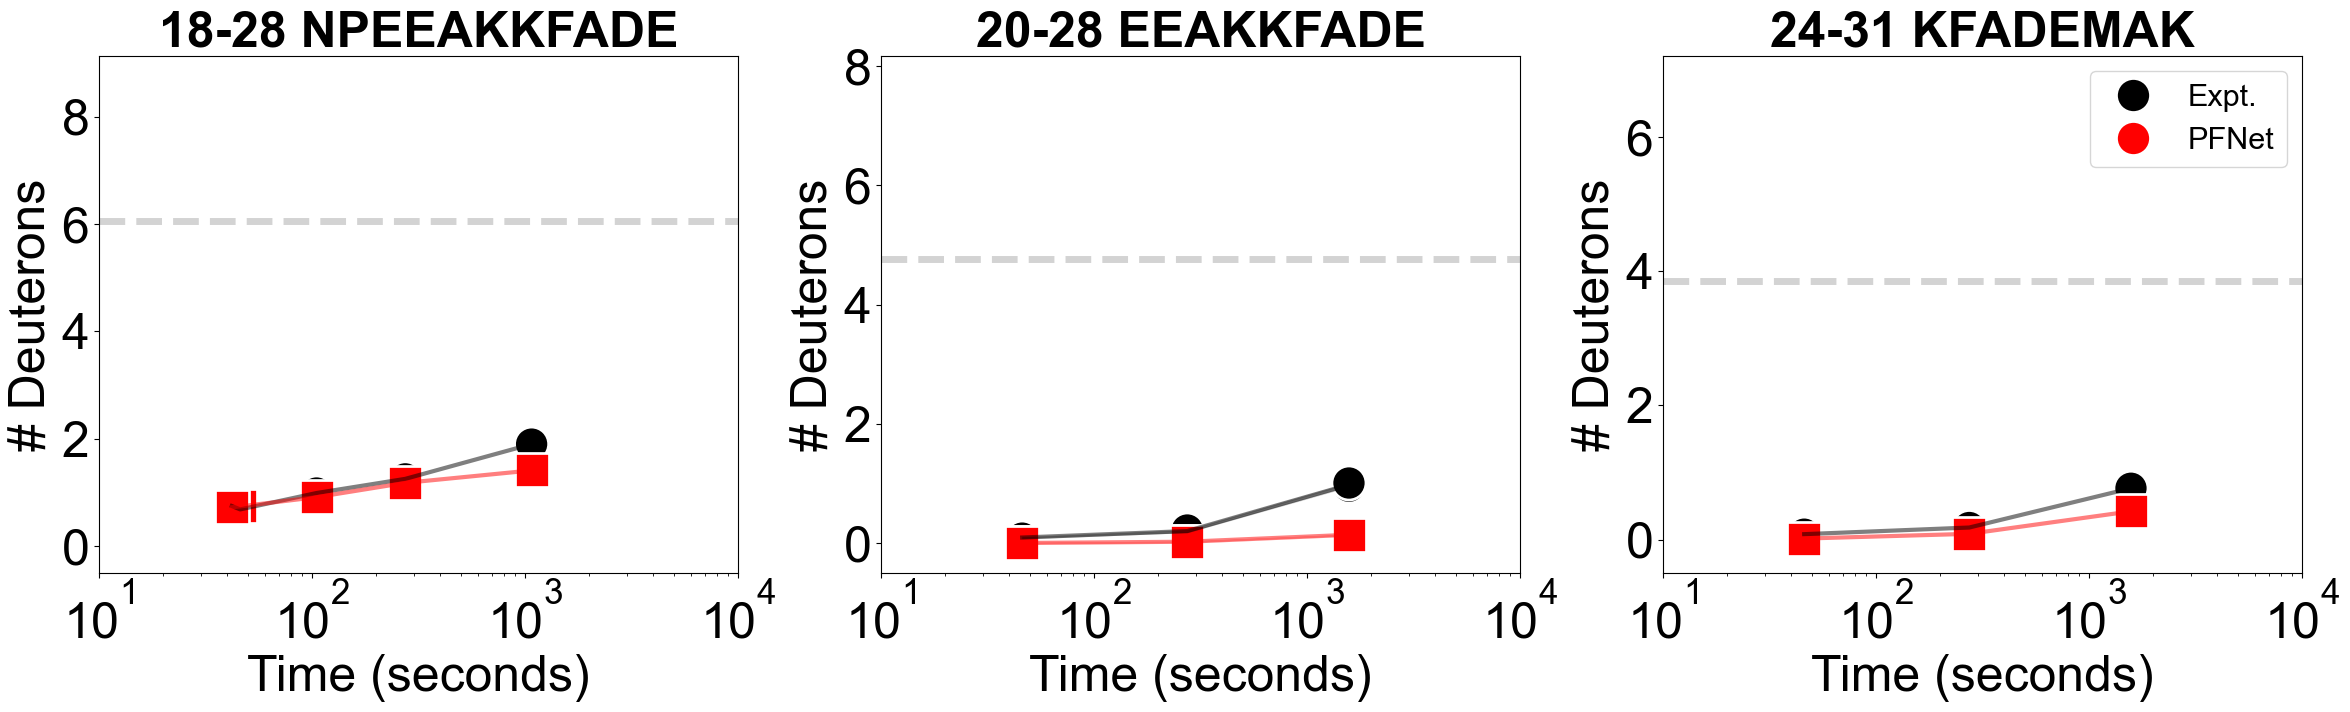

In [7]:
all_peptides = output["hdxms_data_objs"]["hdxms_data_expt"].states[0].peptides
hdxms_data_list = [
    output["hdxms_data_objs"]["hdxms_data_expt"],
    output["hdxms_data_objs"]["hdxms_data_pfnet"],
]
peptide_ids = ["18-28 NPEEAKKFADE", "20-28 EEAKKFADE", "24-31 KFADEMAK"]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for i, peptide_id in enumerate(peptide_ids):
    ax = axes[i]
    peptide = [p for p in all_peptides if p.id == peptide_id][0]
    UptakePlot(
        hdxms_data_list,
        peptide_id,
        if_plot_fit=False,
        figure=fig,
        ax=ax,
        calculate_num_d_from_envelope=True,
    )
    ax.axhline(y=peptide.max_d, color="lightgray", linestyle="--", linewidth=5)
    y_max = peptide.theo_max_d / 0.9
    ax.set_ylim(-0.5, y_max + 0.5)

    if i == len(peptide_ids) - 1:
        exclude_states = ["state", "data_set_index", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [label for label in labels if label not in exclude_states]
        new_handles = [handle for handle, label in zip(handles, labels) if label not in exclude_states]
        ax.legend(new_handles, new_labels, title="", title_fontsize="small", loc="best")
    else:
        ax.legend().remove()

fig.tight_layout()
fig

The uptake plots show the main issue: these peptides remain only weakly exchanged within the observed time window, so the data do not capture enough of the exchange kinetics. That makes this region a good candidate for follow-up measurements at longer labeling times.


## Extend the experiment with longer timepoints

Next we rebuild the dataset, now keeping timepoints up to `40000 s`. This mimics a follow-up experiment designed from the first PFNet result: add later measurements specifically to better resolve slow exchange.


In [8]:
dataset, batch, hxms_data = _load_data(str(source_input_path), centroid_model=False)

info = get_all_statics_info([hxms_data], print_output=False)
print(info)

all_peptides = [peptide for state in hxms_data.states for peptide in state.peptides]
for peptide in all_peptides:
    peptide.timepoints = [tp for tp in peptide.timepoints if tp.deut_time == np.inf or tp.deut_time <= 40000.0]

write_HXMS_files([hxms_data], "GR1_medium")

Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
                    HDX-MS Data Statistics
States names: ['Expt.']
Time course (s): [44.0, 105.0, 261.0, 1074.0, 1574.0, 1772.0, 5073.0, 10073.0, 14269.0, 15071.0, 25072.0, 30071.0, 40071.0, 60073.0]
Number of time points: 14
Protein sequence length: 47
Average coverage: 0.98
Number of unique peptides: 68
Average peptide length: 12.1
Redundancy (based on average coverage): 17.5
Average peptide length to redundancy ratio: 0.7
Backexchange average, IQR: 0.31, 0.12
Wrote ./GR1_medium_Expt..hxms


## Re-run PFNet on the extended dataset

We now rerun PFNet on the updated design and compare the same region against the short-time-window result.


In [9]:
input_path = Path("./GR1_medium_Expt..hxms")
output_path = Path("./pfnet_output_GR1_medium")
output_path.mkdir(parents=True, exist_ok=True)

output = predict(
    input=str(input_path),
    output_json=str(output_path / "pfnet_results.json"),
    centroid_model=False,
    refinement=False,
    uptake_plots=True,
    plots_dir=str(output_path / "uptake_plots"),
    benchmark=False,
)

loading PFNet model
Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
plotting uptake plots


### Reinspect the residue-level confidence

After adding longer timepoints, the confidence around residues `22-30` should increase if the new measurements provide enough information to better resolve the slow-exchange regime.


,resid,resname,avg_dG (kJ/mol),std_dG (kJ/mol),avg_logP (log(sec^-1)),std_logP (log(sec^-1)),log_kch (log(sec^-1)),log_kex (log(sec^-1)),is_nan,coverage,PFNet_confidence,single_resolved,min_pep logPs,min_pep log_kex
17,18,N,19.071,4.061,3.398,0.724,0.664,-2.734,False,35.0,0.890937,True,[3.398],[-2.734]
18,19,P,0.000,0.000,0.000,0.000,-inf,-inf,False,35.0,-100.000000,True,[nan],[-inf]
19,20,E,6.660,4.218,1.187,0.752,-0.464,-1.651,False,36.0,0.886972,True,[1.187],[-1.651]
20,21,E,6.271,1.896,1.117,0.338,-0.350,-1.467,False,37.0,0.947527,True,[1.117],[-1.467]
21,22,A,23.124,2.347,4.120,0.418,-0.252,-4.373,False,33.0,0.936822,False,"[4.416, 3.824]","[-4.668, -4.077]"
22,23,K,23.608,2.347,4.206,0.418,-0.166,-4.373,False,33.0,0.934079,False,"[4.502, 3.91]","[-4.668, -4.077]"
23,24,K,23.211,2.683,4.136,0.478,-0.046,-4.182,False,29.0,0.926563,True,[4.136],[-4.182]
24,25,F,20.210,2.349,3.601,0.418,-0.246,-3.847,False,23.0,0.935399,True,[3.601],[-3.847]
25,26,A,24.272,1.997,4.325,0.356,-0.066,-4.391,False,23.0,0.944791,True,[4.325],[-4.391]
26,27,D,25.198,2.102,4.490,0.374,-0.016,-4.506,False,24.0,0.947381,False,"[4.669, 4.31]","[-4.685, -4.326]"


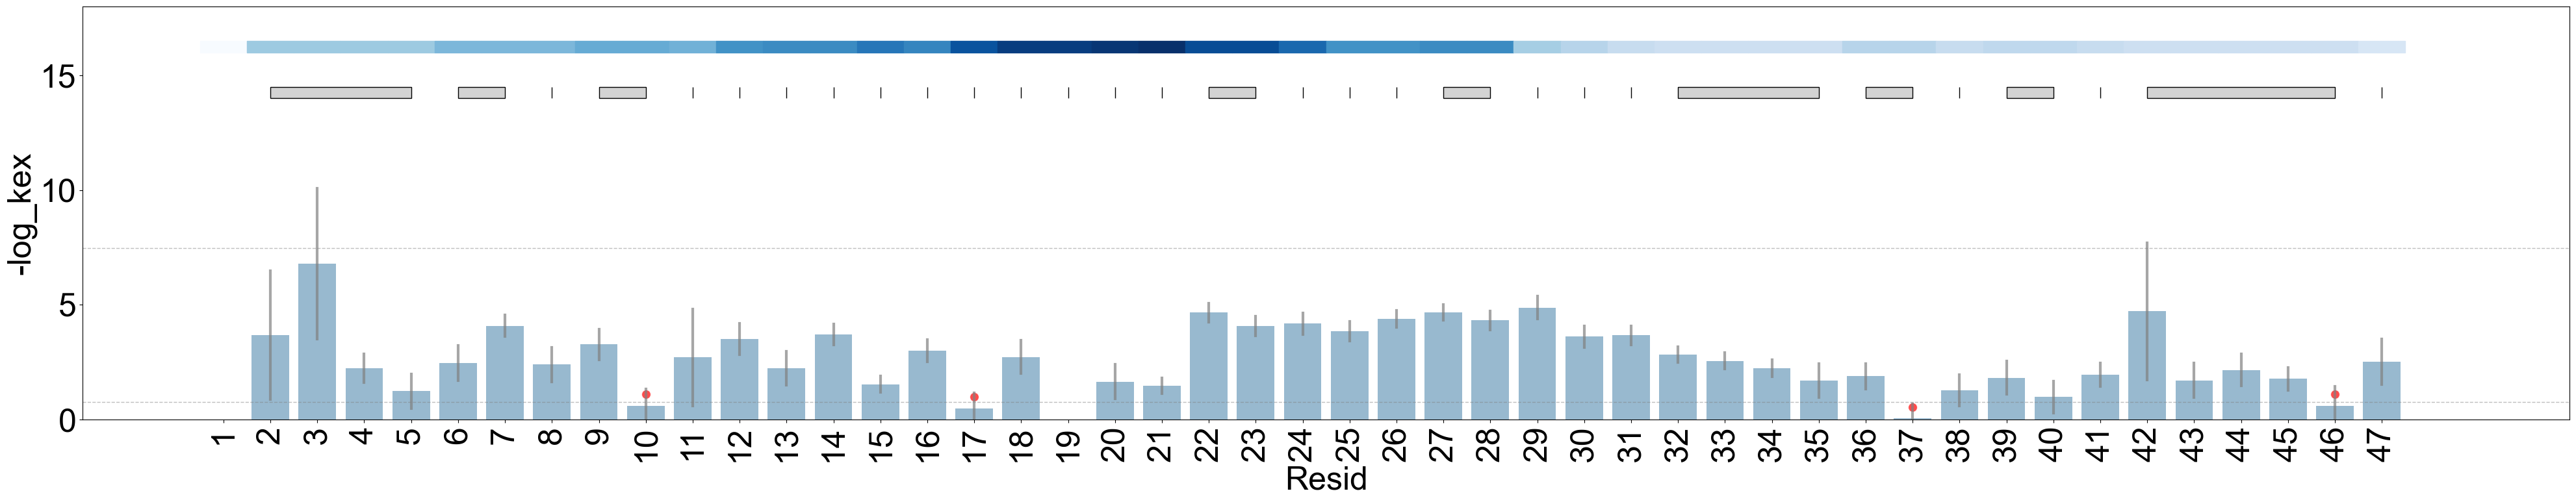

In [10]:
results = output["results"]
analysis_objs = output["analysis_objs"]

fig, ax = plt.subplots(1, 1, figsize=(40, 8), sharey=True, sharex=True)
analysis_objs["analysis_pfnet"].plot_kex_bar(
    ax=ax,
    resolution_indicator_pos=14,
    show_seq=False,
    show_coverage=True,
)

confidence_df = create_logP_df(
    analysis_objs["analysis_pfnet"],
    index_offset=0,
    pfnet_confidence=results["pfnet_pred_log_kex_confidence"],
)

confidence_df.iloc[17:31]

### Compare the same peptides after adding longer timepoints

Finally, we revisit the same overlapping peptides. The goal is not necessarily to span the full saturation regime, but to add enough late-time information that the exchange rates in this region become much better determined.


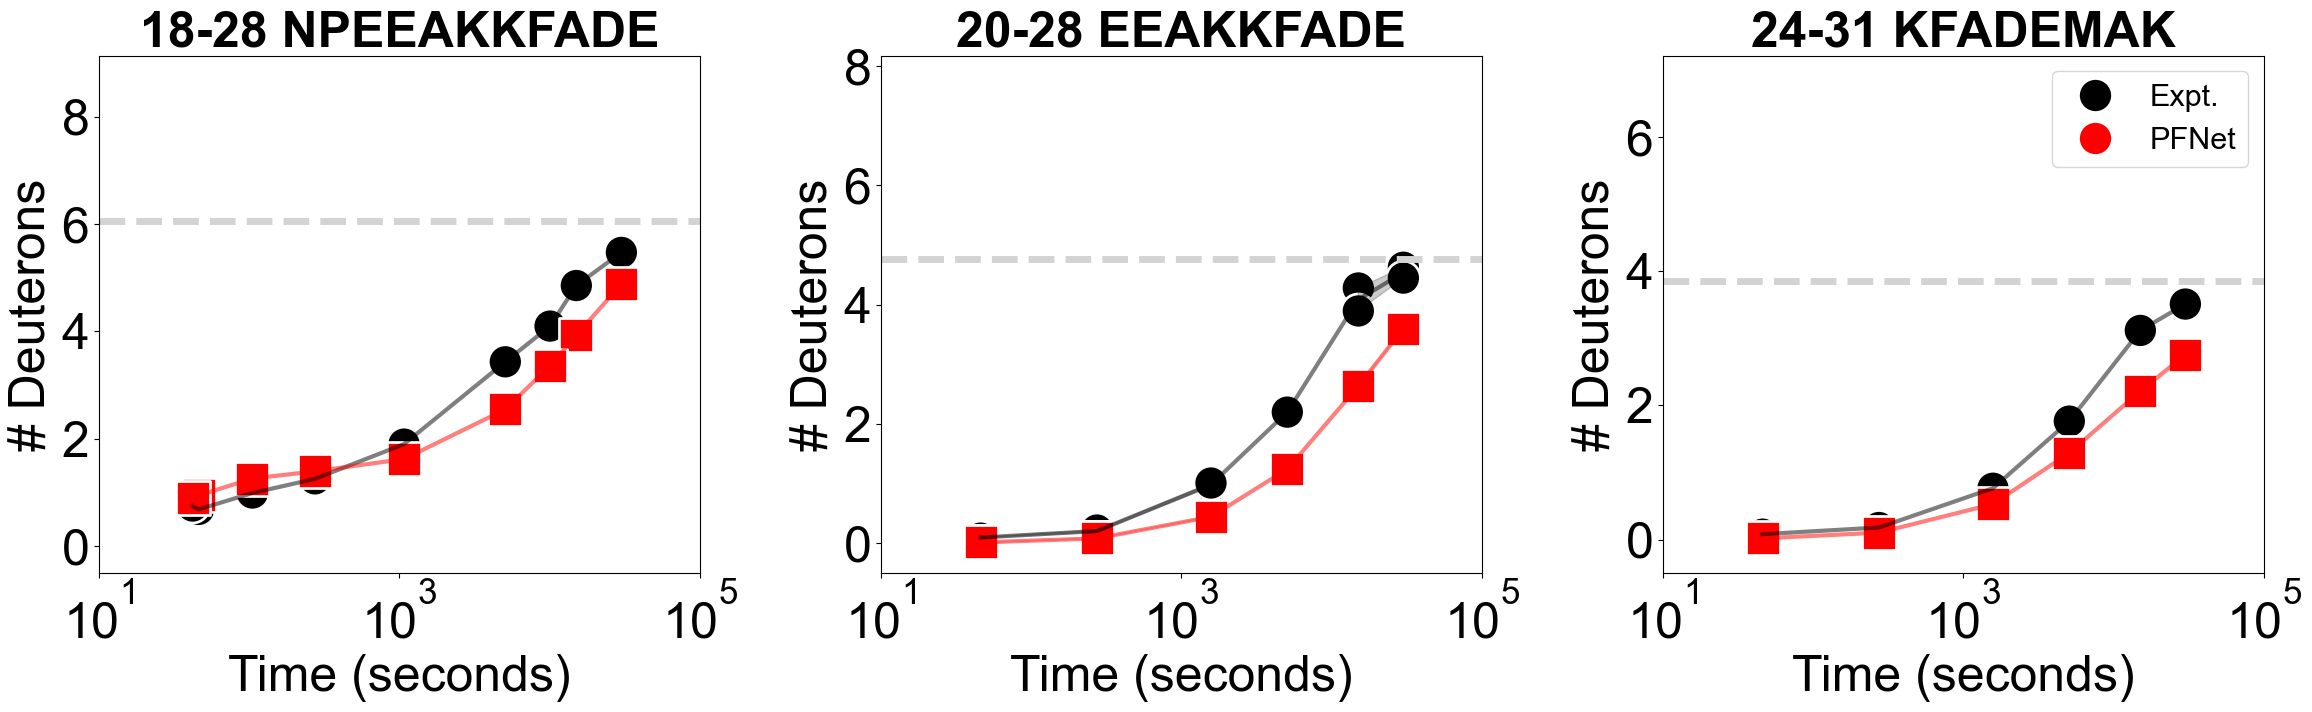

In [11]:
all_peptides = output["hdxms_data_objs"]["hdxms_data_expt"].states[0].peptides
hdxms_data_list = [
    output["hdxms_data_objs"]["hdxms_data_expt"],
    output["hdxms_data_objs"]["hdxms_data_pfnet"],
]

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for i, peptide_id in enumerate(peptide_ids):
    ax = axes[i]
    peptide = [p for p in all_peptides if p.id == peptide_id][0]
    UptakePlot(
        hdxms_data_list,
        peptide_id,
        if_plot_fit=False,
        figure=fig,
        ax=ax,
        calculate_num_d_from_envelope=True,
    )
    ax.axhline(y=peptide.max_d, color="lightgray", linestyle="--", linewidth=5)
    y_max = peptide.theo_max_d / 0.9
    ax.set_ylim(-0.5, y_max + 0.5)

    if i == len(peptide_ids) - 1:
        exclude_states = ["state", "data_set_index", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [label for label in labels if label not in exclude_states]
        new_handles = [handle for handle, label in zip(handles, labels) if label not in exclude_states]
        ax.legend(new_handles, new_labels, title="", title_fontsize="small", loc="best")
    else:
        ax.legend().remove()

fig.tight_layout()
fig

## Summary

This notebook demonstrates a practical PFNet workflow for experiment planning: use an initial inference run to locate low-confidence regions, inspect the peptide-level uptake behavior that causes the uncertainty, then add targeted timepoints and rerun PFNet to see whether the revised design improves residue-level confidence.
